<a href="https://colab.research.google.com/github/huksleva/DataScience/blob/main/%D0%9B%D0%A01/notebooks/LR1_Ames_SelfStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ЛР1 — Основы Data Science
## Ames Housing — задания для самостоятельной работы

**Цель:** выполнить задания для самостоятельной работы по методичке на базе Ames Housing Dataset.

В работе рассматриваются:
- дополнительный Feature Engineering;
- обработка пропусков;
- Linear Regression, Ridge и Lasso;
- анализ остатков;
- 10-fold cross-validation.

## 1. Импорт библиотек

Набор библиотек соответствует методичке.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import skew

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["font.size"] = 10

print("Все библиотеки успешно импортированы!")

Все библиотеки успешно импортированы!


## 2. Загрузка данных

Если в `data/` находится полный `train.csv`, используется он.
Иначе используется демонстрационный набор из методички.

In [ ]:
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = Path.cwd().parent

full_train = project_root / "data" / "train.csv"
demo_train = project_root / "data" / "ames_demo.csv"

if full_train.exists():
    df = pd.read_csv(full_train)
    print(f"Загружен полный датасет: {full_train}")
else:
    df = pd.read_csv(demo_train)
    print(f"Загружен демонстрационный датасет: {demo_train}")

print(f"Размер данных: {df.shape}")
display(df.head())

Загружен демонстрационный датасет: C:\Leo\projects\Datascience\ЛР1\data\ames_demo.csv
Размер данных: (20, 29)


,Id,MSSubClass,LotFrontage,LotArea,Street,Alley,LotShape,Utilities,LotConfig,Neighborhood,...,BsmtQual,BsmtFinSF1,TotalBsmtSF,GrLivArea,FullBath,BedroomAbvGr,KitchenQual,GarageType,GarageArea,SalePrice
0,1,60,65.0,8450,Pave,NaN,Reg,AllPub,Inside,CollgCr,...,Gd,706,856,1710,2,3,Gd,Attchd,548,208500
1,2,20,80.0,9600,Pave,NaN,Reg,AllPub,FR2,Veenker,...,Gd,978,1262,1262,2,3,TA,Attchd,460,181500
2,3,60,68.0,11250,Pave,NaN,IR1,AllPub,Inside,CollgCr,...,Gd,486,920,1786,2,3,Gd,Attchd,608,223500
3,4,70,60.0,9550,Pave,NaN,IR1,AllPub,Corner,Crawfor,...,TA,216,756,1717,1,3,Gd,Detchd,642,140000
4,5,60,84.0,14260,Pave,NaN,IR1,AllPub,FR2,NoRidge,...,Gd,655,1145,2198,2,4,Gd,Attchd,836,250000


## 3. Первичный анализ данных

In [ ]:
print("Размер датасета:", df.shape)
print("\nТипы данных:")
display(df.dtypes.to_frame("dtype"))

print("\nОсновная статистика:")
display(df.describe(include="all").T)

print("\nКоличество пропусков:")
display(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

Размер датасета: (20, 29)

Типы данных:


,dtype
Id,int64
MSSubClass,int64
LotFrontage,float64
LotArea,int64
Street,str
Alley,float64
LotShape,str
Utilities,str
LotConfig,str
Neighborhood,str



Основная статистика:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,20.0,NaN,NaN,NaN,10.5,5.91608,1.0,5.75,10.5,15.25,20.0
MSSubClass,20.0,NaN,NaN,NaN,48.75,39.864078,20.0,20.0,47.5,60.0,190.0
LotFrontage,17.0,NaN,NaN,NaN,71.352941,13.033328,50.0,63.0,74.0,81.0,91.0
LotArea,20.0,NaN,NaN,NaN,9926.75,2351.303085,6120.0,8212.5,9842.0,11212.5,14260.0
Street,20,1,Pave,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alley,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotShape,20,2,Reg,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Utilities,20,1,AllPub,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotConfig,20,3,Inside,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Neighborhood,20,12,NAmes,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Количество пропусков:


Alley          20
MasVnrType     13
LotFrontage     3
dtype: int64

## 4. Анализ пропущенных значений

,Количество пропусков,Процент пропусков
Alley,20,100.0
MasVnrType,13,65.0
LotFrontage,3,15.0


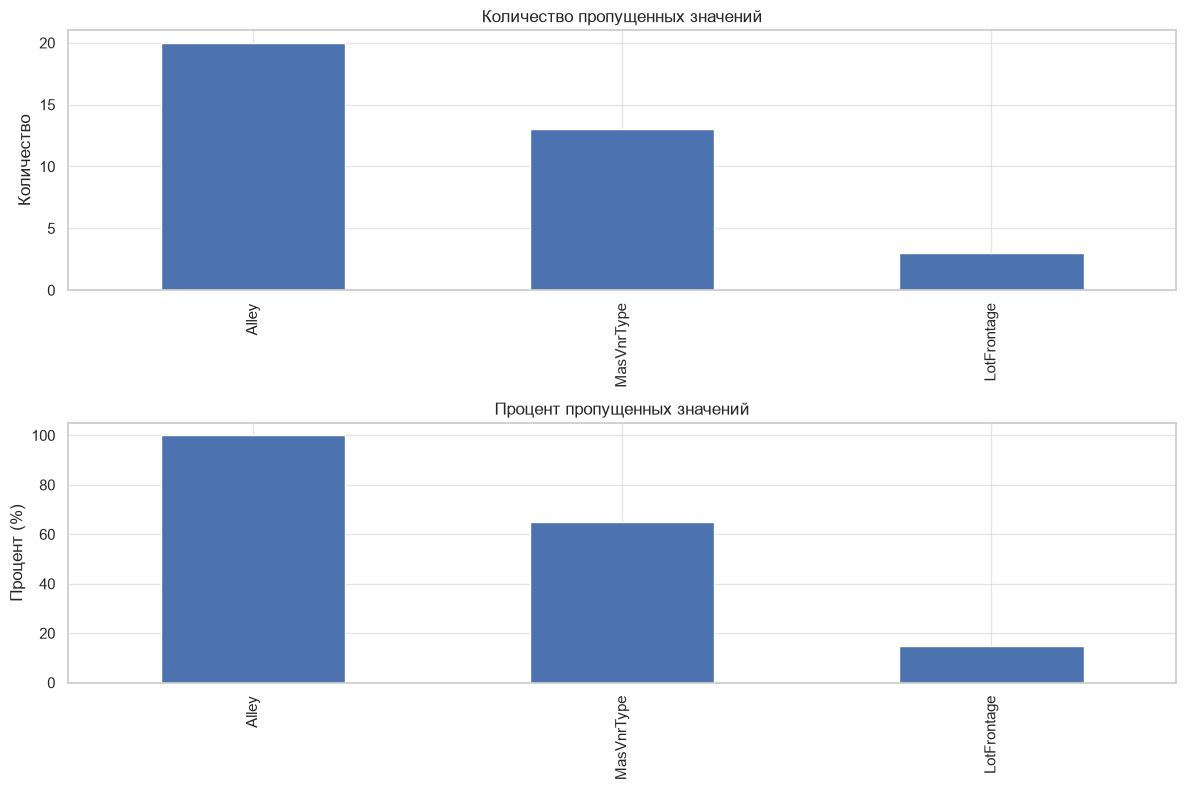

Признаков с пропусками: 3


In [ ]:
def analyze_missing_values(dataframe):
    missing_data = dataframe.isnull().sum()
    missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
    missing_percent = (missing_data / len(dataframe)) * 100

    return pd.DataFrame({
        "Количество пропусков": missing_data,
        "Процент пропусков": missing_percent
    })

missing_analysis = analyze_missing_values(df)

if len(missing_analysis) > 0:
    display(missing_analysis)

    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    missing_analysis["Количество пропусков"].plot(kind="bar", ax=axes[0])
    axes[0].set_title("Количество пропущенных значений")
    axes[0].set_ylabel("Количество")

    missing_analysis["Процент пропусков"].plot(kind="bar", ax=axes[1])
    axes[1].set_title("Процент пропущенных значений")
    axes[1].set_ylabel("Процент (%)")

    plt.tight_layout()
    plt.show()

    print(f"Признаков с пропусками: {len(missing_analysis)}")
else:
    print("Пропущенных значений не найдено.")

## 5. Обработка пропусков — текущий метод из методички

In [ ]:
def handle_missing_values(dataframe):
    dataframe = dataframe.copy()

    # Отсутствующий объект трактуем как отсутствие объекта
    categorical_na_as_none = ["Alley", "MasVnrType", "BsmtQual", "GarageType"]

    for feature in categorical_na_as_none:
        if feature in dataframe.columns:
            dataframe[feature] = dataframe[feature].fillna("None")

    # Отсутствующий объект -> площадь 0
    if "MasVnrArea" in dataframe.columns:
        dataframe["MasVnrArea"] = dataframe["MasVnrArea"].fillna(0)

    # Остальные числовые признаки -> медиана
    numeric_features = dataframe.select_dtypes(include=[np.number]).columns
    for feature in numeric_features:
        if dataframe[feature].isnull().sum() > 0:
            dataframe[feature] = dataframe[feature].fillna(dataframe[feature].median())

    # Остальные категориальные признаки -> мода
    categorical_features = dataframe.select_dtypes(include=["object"]).columns
    for feature in categorical_features:
        if dataframe[feature].isnull().sum() > 0:
            dataframe[feature] = dataframe[feature].fillna(dataframe[feature].mode()[0])

    return dataframe

df_processed = handle_missing_values(df)

print("Оставшиеся пропуски:", df_processed.isnull().sum().sum())

Оставшиеся пропуски: 0


## 6. Feature Engineering из основной части методички

In [ ]:
def create_new_features(dataframe):
    df_new = dataframe.copy()
    current_year = 2023

    if "YearBuilt" in df_new.columns:
        df_new["HouseAge"] = current_year - df_new["YearBuilt"]

    if "YearRemodAdd" in df_new.columns:
        df_new["YearsSinceRemod"] = current_year - df_new["YearRemodAdd"]

    if all(col in df_new.columns for col in ["TotalBsmtSF", "GrLivArea"]):
        df_new["TotalSF"] = df_new["TotalBsmtSF"] + df_new["GrLivArea"]

    if "FullBath" in df_new.columns:
        df_new["TotalBathrooms"] = (
            df_new["FullBath"] + df_new.get("HalfBath", 0) * 0.5
        )

    if all(col in df_new.columns for col in ["GarageArea", "GrLivArea"]):
        df_new["GarageRatio"] = (df_new["GarageArea"] / df_new["GrLivArea"] + 1)

    if "OverallQual" in df_new.columns:
        df_new["QualityCategory"] = pd.cut(
            df_new["OverallQual"],
            bins=[0, 4, 7, 10],
            labels=["Low", "Medium", "High"]
        )

    if all(col in df_new.columns for col in ["OverallQual", "GrLivArea"]):
        df_new["IsPremium"] = (
            (df_new["OverallQual"] >= 8)
            & (df_new["GrLivArea"] > df_new["GrLivArea"].quantile(0.75))
        ).astype(int)

    return df_new

df_processed = create_new_features(df_processed)
print("Размер после Feature Engineering:", df_processed.shape)
display(df_processed.head())

Размер после Feature Engineering: (20, 36)


,Id,MSSubClass,LotFrontage,LotArea,Street,Alley,LotShape,Utilities,LotConfig,Neighborhood,...,GarageType,GarageArea,SalePrice,HouseAge,YearsSinceRemod,TotalSF,TotalBathrooms,GarageRatio,QualityCategory,IsPremium
0,1,60,65.0,8450,Pave,None,Reg,AllPub,Inside,CollgCr,...,Attchd,548,208500,20,20,2566,2.0,0.320468,Medium,0
1,2,20,80.0,9600,Pave,None,Reg,AllPub,FR2,Veenker,...,Attchd,460,181500,47,47,2524,2.0,0.364501,Medium,0
2,3,60,68.0,11250,Pave,None,IR1,AllPub,Inside,CollgCr,...,Attchd,608,223500,22,21,2706,2.0,0.340426,Medium,0
3,4,70,60.0,9550,Pave,None,IR1,AllPub,Corner,Crawfor,...,Detchd,642,140000,108,53,2473,1.0,0.373908,Medium,0
4,5,60,84.0,14260,Pave,None,IR1,AllPub,FR2,NoRidge,...,Attchd,836,250000,23,23,3343,2.0,0.380346,High,1


## 7. Кодирование категориальных признаков

In [ ]:
def encode_categorical_features(dataframe):
    """Кодирует категориальные признаки"""
    print("\nКОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:")
    print("=" * 50)

    df_encoded = dataframe.copy()

    # Порядковые признаки
    ordinal_mappings = {
        'OverallQual': {i: i - 1 for i in range(1, 11)},
        'OverallCond': {i: i - 1 for i in range(1, 11)},
        'BsmtQual': {
            'None': 0,
            'Po': 1,
            'Fa': 2,
            'TA': 3,
            'Gd': 4,
            'Ex': 5
        },
        'KitchenQual': {
            'Po': 0,
            'Fa': 1,
            'TA': 2,
            'Gd': 3,
            'Ex': 4
        },
        'QualityCategory': {
            'Low': 0,
            'Medium': 1,
            'High': 2
        }
    }

    # Кодируем порядковые признаки
    for feature, mapping in ordinal_mappings.items():
        if feature in df_encoded.columns:
            df_encoded[f'{feature}_encoded'] = (
                df_encoded[feature].map(mapping).fillna(0)
            )

            print(f"✓ {feature} закодирован как порядковый")

            # Исходный столбец больше не нужен
            df_encoded.drop(columns=[feature], inplace=True)

    # Находим все оставшиеся категориальные признаки
    categorical_features = df_encoded.select_dtypes(
        include=['object', 'category']
    ).columns.tolist()

    # One-Hot Encoding для ВСЕХ оставшихся категориальных признаков
    if categorical_features:
        print("\nOne-Hot Encoding:")

        df_encoded = pd.get_dummies(
            df_encoded,
            columns=categorical_features,
            drop_first=True,
            dtype=int
        )

        for feature in categorical_features:
            print(f"✓ {feature} → One-Hot Encoding")

    print(
        f"\nРазмер после кодирования: {df_encoded.shape}"
    )

    # Проверка: строковых признаков остаться не должно
    remaining_categorical = df_encoded.select_dtypes(
        include=['object', 'category']
    ).columns.tolist()

    print(
        "Оставшиеся категориальные признаки:",
        remaining_categorical
    )

    return df_encoded

In [ ]:
# Кодируем категориальные признаки
df_encoded = encode_categorical_features(df_processed)

print("Размер после кодирования:", df_encoded.shape)


КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:
✓ OverallQual закодирован как порядковый
✓ OverallCond закодирован как порядковый
✓ BsmtQual закодирован как порядковый
✓ KitchenQual закодирован как порядковый
✓ QualityCategory закодирован как порядковый

One-Hot Encoding:
✓ Street → One-Hot Encoding
✓ Alley → One-Hot Encoding
✓ LotShape → One-Hot Encoding
✓ Utilities → One-Hot Encoding
✓ LotConfig → One-Hot Encoding
✓ Neighborhood → One-Hot Encoding
✓ RoofStyle → One-Hot Encoding
✓ Exterior1st → One-Hot Encoding
✓ MasVnrType → One-Hot Encoding
✓ Foundation → One-Hot Encoding
✓ GarageType → One-Hot Encoding
✓ QualityCategory_encoded → One-Hot Encoding

Размер после кодирования: (20, 53)
Оставшиеся категориальные признаки: []
Размер после кодирования: (20, 53)


In [ ]:
def prepare_features(dataframe, target_column="SalePrice"):
    X = dataframe.drop([target_column, "Id"], axis=1, errors="ignore").copy()
    y = dataframe[target_column].copy()

    target_skewness = skew(y)

    if abs(target_skewness) > 0.5:
        y_transformed = np.log1p(y)
        print(
            f"SalePrice преобразован: skewness "
            f"{target_skewness:.3f} -> {skew(y_transformed):.3f}"
        )
    else:
        y_transformed = y
        print(f"SalePrice не требует преобразования: skewness={target_skewness:.3f}")

    numeric_features = X.select_dtypes(include=[np.number]).columns
    skewed_features = []

    for feature in numeric_features:
        if X[feature].nunique() > 10:
            feature_skewness = skew(X[feature])
            if abs(feature_skewness) > 0.75:
                skewed_features.append(feature)

    X_transformed = X.copy()

    for feature in skewed_features:
        # В методичке log1p применяется к скошенным числовым признакам
        X_transformed[feature] = np.log1p(X_transformed[feature].clip(lower=0))

    print("Сильно скошенные признаки:", skewed_features)
    return X_transformed, y_transformed, skewed_features

X_processed, y_processed, skewed_features = prepare_features(df_encoded)

print("X:", X_processed.shape)
print("y:", y_processed.shape)

SalePrice преобразован: skewness 1.026 -> 0.457
Сильно скошенные признаки: []
X: (20, 51)
y: (20,)


## 8. Подготовка признаков и логарифмическое преобразование

## 9. Train/Test и базовые модели

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y_processed,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (16, 51)
Размер тестовой выборки: (4, 51)


In [ ]:
def train_and_evaluate_models(
    X_train, X_test, y_train, y_test,
    X_train_scaled, X_test_scaled
):
    models = {}
    results = {}

    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    lr_pred = lr.predict(X_test)

    models["Linear"] = lr
    results["Linear"] = {
        "predictions": lr_pred,
        "mae": mean_absolute_error(y_test, lr_pred),
        "mse": mean_squared_error(y_test, lr_pred),
        "r2": r2_score(y_test, lr_pred)
    }

    # Ridge
    ridge_params = {"alpha": [0.1, 1.0, 10.0, 100.0, 1000.0]}
    ridge_grid = GridSearchCV(
        Ridge(),
        ridge_params,
        cv=5,
        scoring="r2"
    )
    ridge_grid.fit(X_train_scaled, y_train)

    best_ridge = ridge_grid.best_estimator_
    ridge_pred = best_ridge.predict(X_test_scaled)

    models["Ridge"] = best_ridge
    results["Ridge"] = {
        "predictions": ridge_pred,
        "mae": mean_absolute_error(y_test, ridge_pred),
        "mse": mean_squared_error(y_test, ridge_pred),
        "r2": r2_score(y_test, ridge_pred),
        "best_alpha": ridge_grid.best_params_["alpha"]
    }

    # Lasso
    lasso_params = {"alpha": [0.001, 0.01, 0.1, 1.0, 10.0]}
    lasso_grid = GridSearchCV(
        Lasso(max_iter=10000),
        lasso_params,
        cv=5,
        scoring="r2"
    )
    lasso_grid.fit(X_train_scaled, y_train)

    best_lasso = lasso_grid.best_estimator_
    lasso_pred = best_lasso.predict(X_test_scaled)

    models["Lasso"] = best_lasso
    results["Lasso"] = {
        "predictions": lasso_pred,
        "mae": mean_absolute_error(y_test, lasso_pred),
        "mse": mean_squared_error(y_test, lasso_pred),
        "r2": r2_score(y_test, lasso_pred),
        "best_alpha": lasso_grid.best_params_["alpha"],
        "n_features_used": int(np.sum(best_lasso.coef_ != 0))
    }

    return models, results

models, results = train_and_evaluate_models(
    X_train, X_test, y_train, y_test,
    X_train_scaled, X_test_scaled
)

results_table = pd.DataFrame({
    name: {
        "MAE": value["mae"],
        "MSE": value["mse"],
        "R²": value["r2"]
    }
    for name, value in results.items()
}).T

display(results_table)

,MAE,MSE,R²
Linear,0.273639,0.119932,-0.146221
Ridge,0.186577,0.068583,0.344531
Lasso,0.189153,0.052560,0.497666


# Задание 1. Дополнительный Feature Engineering

По методичке необходимо создать:
- `PricePerSqFt`;
- `AgeCategory`;
- `HasGarage`.

In [ ]:
def create_additional_features(dataframe):
    df_new = dataframe.copy()

    # Цена за квадратный фут.
    # Этот признак используется только для анализа,
    # потому что SalePrice является целевой переменной.
    if "SalePrice" in df_new.columns and "GrLivArea" in df_new.columns:
        df_new["PricePerSqFt"] = df_new["SalePrice"] / df_new["GrLivArea"]

    # Категория возраста дома
    df_new['AgeCategory'] = pd.cut(
        df_new['HouseAge'],
        bins=[-np.inf, 10, 30, np.inf],
        labels=['New', 'Medium', 'Old']
    )

    # Наличие гаража
    if "GarageArea" in df_new.columns:
        df_new["HasGarage"] = (
            df_new["GarageArea"] > 0
        ).astype(int)

    return df_new

df_additional = create_additional_features(df_processed)

print("Новые признаки:")
display(
    df_additional[
        [c for c in ["PricePerSqFt", "HouseAge", "AgeCategory", "HasGarage"]
         if c in df_additional.columns]
    ].head(10)
)

print("\nРаспределение AgeCategory:")
display(df_additional["AgeCategory"].value_counts(dropna=False))

print("\nРаспределение HasGarage:")
display(df_additional["HasGarage"].value_counts(dropna=False))

Новые признаки:


,PricePerSqFt,HouseAge,AgeCategory,HasGarage
0,121.858562,20,Medium,1
1,143.705463,47,Old,1
2,125.069950,22,Medium,1
3,81.490105,108,Old,1
4,113.688040,23,Medium,1
5,104.915627,30,Medium,1
6,181.120944,19,Medium,1
7,95.648015,50,Old,1
8,73.183099,92,Old,1
9,109.461967,84,Old,1



Распределение AgeCategory:


AgeCategory
Old       13
Medium     7
New        0
Name: count, dtype: int64


Распределение HasGarage:


HasGarage
1    20
Name: count, dtype: int64

### Анализ PricePerSqFt

`PricePerSqFt` нельзя передавать в модель прогнозирования `SalePrice`, поскольку он вычислен с использованием самой `SalePrice`. Это демонстрационный признак из задания методички.

Корреляция PricePerSqFt с SalePrice: 0.507


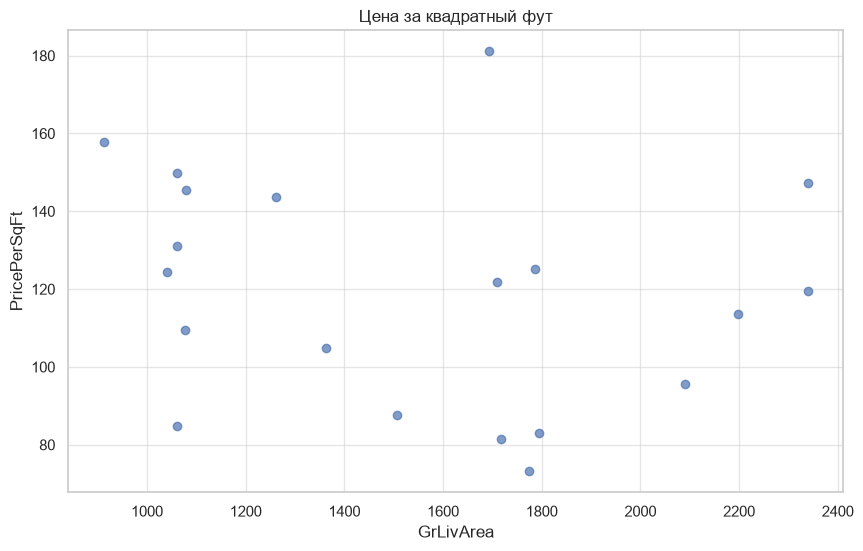

In [ ]:
if "PricePerSqFt" in df_additional.columns:
    print(
        f"Корреляция PricePerSqFt с SalePrice: "
        f"{df_additional['PricePerSqFt'].corr(df_additional['SalePrice']):.3f}"
    )

    plt.figure(figsize=(10, 6))
    plt.scatter(
        df_additional["GrLivArea"],
        df_additional["PricePerSqFt"],
        alpha=0.7
    )
    plt.xlabel("GrLivArea")
    plt.ylabel("PricePerSqFt")
    plt.title("Цена за квадратный фут")
    plt.show()

### Проверка влияния `HasGarage`

Для проверки влияния признака можно сравнить среднюю цену домов с гаражом и без гаража.

In [ ]:
garage_comparison = (
    df_additional
    .groupby("HasGarage")["SalePrice"]
    .agg(["mean", "median", "count"])
)

display(garage_comparison)

,mean,median,count
HasGarage,,,
1,181270.0,153000.0,20


# Задание 2. Улучшение обработки пропусков

Используем `KNNImputer` для всех числовых признаков с пропусками и сравним его с текущим подходом.

В соответствии с методичкой KNN используется для числовых признаков.

In [ ]:
# Копия исходных данных
df_knn = df.copy()

# Только числовые признаки, исключая Id и целевую переменную
numeric_cols = df_knn.select_dtypes(include=[np.number]).columns.tolist()

for col in ["Id", "SalePrice"]:
    if col in numeric_cols:
        numeric_cols.remove(col)

print("Числовые признаки для KNN:")
print(numeric_cols)

# Проверяем признаки, полностью состоящие из пропусков
all_nan_cols = [
    col for col in numeric_cols
    if df_knn[col].isna().all()
]

print("\nПризнаки, полностью состоящие из пропусков:")
print(all_nan_cols)

# KNN не может восстановить полностью пустой столбец,
# поэтому сначала исключаем такие признаки
knn_cols = [
    col for col in numeric_cols
    if col not in all_nan_cols
]

# KNNImputer
knn_imputer = KNNImputer(n_neighbors=5)

knn_values = knn_imputer.fit_transform(
    df_knn[knn_cols]
)

# Возвращаем результат в DataFrame
knn_values = pd.DataFrame(
    knn_values,
    columns=knn_cols,
    index=df_knn.index
)

df_knn[knn_cols] = knn_values

print(
    "\nПропусков после KNNImputer:",
    df_knn[knn_cols].isnull().sum().sum()
)

Числовые признаки для KNN:
['MSSubClass', 'LotFrontage', 'LotArea', 'Alley', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'TotalBsmtSF', 'GrLivArea', 'FullBath', 'BedroomAbvGr', 'GarageArea']

Признаки, полностью состоящие из пропусков:
['Alley']

Пропусков после KNNImputer: 0


In [ ]:
# Текущий метод: медиана для числовых признаков
df_median = df.copy()

for feature in numeric_cols:
    if df_median[feature].isnull().sum() > 0:
        df_median[feature] = df_median[feature].fillna(
            df_median[feature].median()
        )

# KNNImputer
df_knn = df.copy()

knn_imputer = KNNImputer(n_neighbors=5)

# Используем только признаки, которые не полностью состоят из NaN
df_knn[knn_cols] = knn_imputer.fit_transform(
    df_knn[knn_cols]
)

print(
    "Пропуски после медианного метода:",
    df_median[numeric_cols].isnull().sum().sum()
)

print(
    "Пропуски после KNNImputer:",
    df_knn[knn_cols].isnull().sum().sum()
)

if "LotFrontage" in df.columns:
    comparison = pd.DataFrame({
        "Исходное": df["LotFrontage"],
        "Медиана": df_median["LotFrontage"],
        "KNN": df_knn["LotFrontage"]
    })

    display(comparison)

Пропуски после медианного метода: 20
Пропуски после KNNImputer: 0


,Исходное,Медиана,KNN
0,65.0,65.0,65.0
1,80.0,80.0,80.0
2,68.0,68.0,68.0
3,60.0,60.0,60.0
4,84.0,84.0,84.0
5,85.0,85.0,85.0
6,75.0,75.0,75.0
7,NaN,74.0,79.0
8,51.0,51.0,51.0
9,50.0,50.0,50.0


### Сравнение корреляции для LotFrontage

Это дополнительная проверка, аналогичная демонстрации из методички.

In [ ]:
if "LotFrontage" in df.columns and df["LotFrontage"].isnull().sum() > 0:
    print("Корреляция LotFrontage с SalePrice:")
    print(f"Медиана: {df_median['LotFrontage'].corr(df_median['SalePrice']):.3f}")
    print(f"KNN:     {df_knn['LotFrontage'].corr(df_knn['SalePrice']):.3f}")

Корреляция LotFrontage с SalePrice:
Медиана: 0.473
KNN:     0.470


### Сравнение качества моделей после KNNImputer

Чтобы сравнение было корректным, повторяем тот же preprocessing и тот же набор моделей.

In [ ]:
def build_model_data(dataframe, imputation="median"):
    data = dataframe.copy()

    # Специальные пропуски
    for feature in ["Alley", "MasVnrType", "BsmtQual", "GarageType"]:
        if feature in data.columns:
            data[feature] = data[feature].fillna("None")

    if "MasVnrArea" in data.columns:
        data["MasVnrArea"] = data["MasVnrArea"].fillna(0)

    numeric_features = data.select_dtypes(include=[np.number]).columns.tolist()
    numeric_without_target = [
        c for c in numeric_features
        if c not in ["Id", "SalePrice"]
    ]

    if imputation == "knn":
        # KNNImputer не может восстановить признак,
        # если в нём отсутствуют все значения
        knn_columns = [
            c for c in numeric_without_target
            if not data[c].isna().all()
        ]

        imputer = KNNImputer(n_neighbors=5)

        data[knn_columns] = imputer.fit_transform(
            data[knn_columns]
        )
    else:
        for feature in numeric_without_target:
            if data[feature].isnull().sum() > 0:
                data[feature] = data[feature].fillna(data[feature].median())

    # Остальные категориальные -> мода
    categorical_features = data.select_dtypes(include=["object"]).columns
    for feature in categorical_features:
        if data[feature].isnull().sum() > 0:
            data[feature] = data[feature].fillna(data[feature].mode()[0])

    data = create_new_features(data)
    data = encode_categorical_features(data)

    X, y, _ = prepare_features(data)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    _, result = train_and_evaluate_models(
        X_train, X_test, y_train, y_test,
        X_train_scaled, X_test_scaled
    )

    return result

median_results = build_model_data(df, "median")
knn_results = build_model_data(df, "knn")

imputation_comparison = pd.DataFrame({
    "Median": {
        model: values["r2"] for model, values in median_results.items()
    },
    "KNN": {
        model: values["r2"] for model, values in knn_results.items()
    }
})

display(imputation_comparison)

best_median = imputation_comparison["Median"].max()
best_knn = imputation_comparison["KNN"].max()

print(f"Лучший R² при медианной обработке: {best_median:.4f}")
print(f"Лучший R² при KNNImputer: {best_knn:.4f}")

if best_knn > best_median:
    print("Вывод: KNNImputer показал лучшее качество на тестовой выборке.")
elif best_knn < best_median:
    print("Вывод: текущий метод показал лучшее качество на тестовой выборке.")
else:
    print("Вывод: качество методов оказалось одинаковым.")


КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:
✓ OverallQual закодирован как порядковый
✓ OverallCond закодирован как порядковый
✓ BsmtQual закодирован как порядковый
✓ KitchenQual закодирован как порядковый
✓ QualityCategory закодирован как порядковый

One-Hot Encoding:
✓ Street → One-Hot Encoding
✓ Alley → One-Hot Encoding
✓ LotShape → One-Hot Encoding
✓ Utilities → One-Hot Encoding
✓ LotConfig → One-Hot Encoding
✓ Neighborhood → One-Hot Encoding
✓ RoofStyle → One-Hot Encoding
✓ Exterior1st → One-Hot Encoding
✓ MasVnrType → One-Hot Encoding
✓ Foundation → One-Hot Encoding
✓ GarageType → One-Hot Encoding
✓ QualityCategory_encoded → One-Hot Encoding

Размер после кодирования: (20, 53)
Оставшиеся категориальные признаки: []
SalePrice преобразован: skewness 1.026 -> 0.457
Сильно скошенные признаки: []

КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:
✓ OverallQual закодирован как порядковый
✓ OverallCond закодирован как порядковый
✓ BsmtQual закодирован как порядковый
✓ KitchenQual закодирован как порядков

,Median,KNN
Linear,-0.146221,0.300041
Ridge,0.344531,0.346073
Lasso,0.497666,0.497690


Лучший R² при медианной обработке: 0.4977
Лучший R² при KNNImputer: 0.4977
Вывод: KNNImputer показал лучшее качество на тестовой выборке.


# Задание 3. Анализ остатков

Остаток определяется как:

**residual = фактическое значение − предсказанное значение**

Проверяем:
1. residuals vs predicted;
2. Q-Q plot;
3. наличие систематических паттернов.

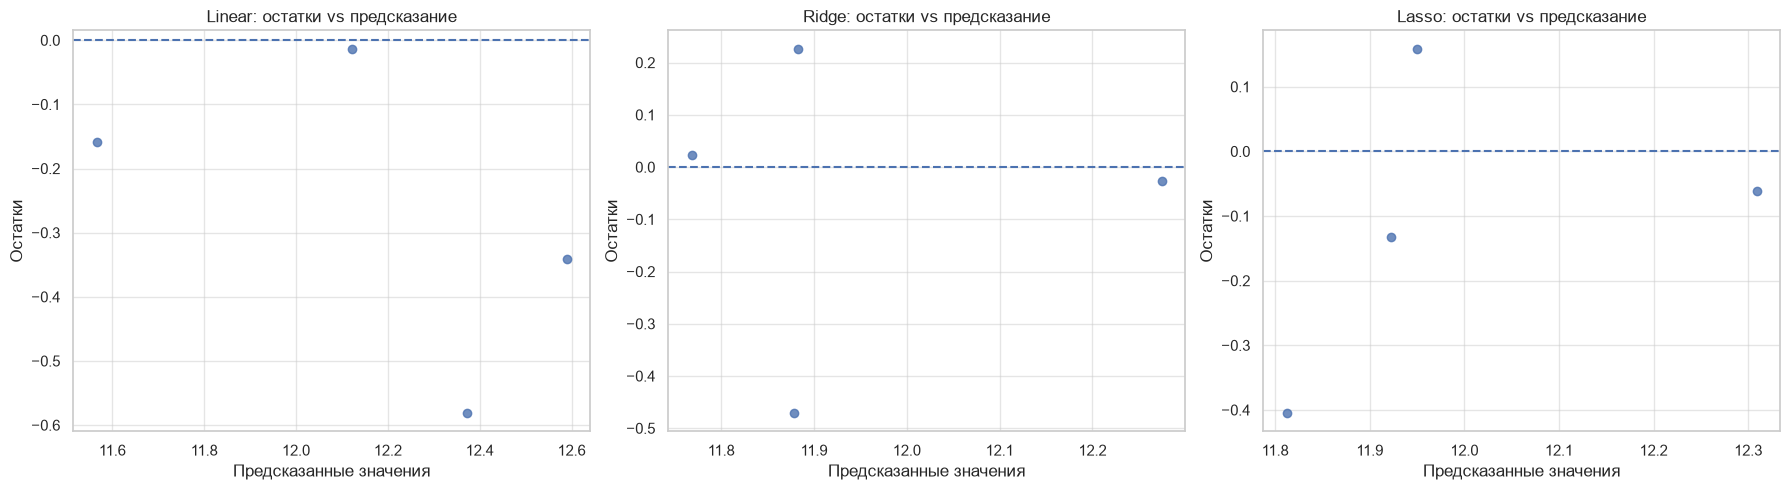

In [ ]:
residuals = {}

for model_name, model_result in results.items():
    residuals[model_name] = (
        y_test.values - model_result["predictions"]
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model_name in zip(axes, residuals.keys()):
    predicted = results[model_name]["predictions"]
    resid = residuals[model_name]

    ax.scatter(predicted, resid, alpha=0.8)
    ax.axhline(0, linestyle="--")
    ax.set_title(f"{model_name}: остатки vs предсказание")
    ax.set_xlabel("Предсказанные значения")
    ax.set_ylabel("Остатки")

plt.tight_layout()
plt.show()

### Q-Q plots для всех моделей

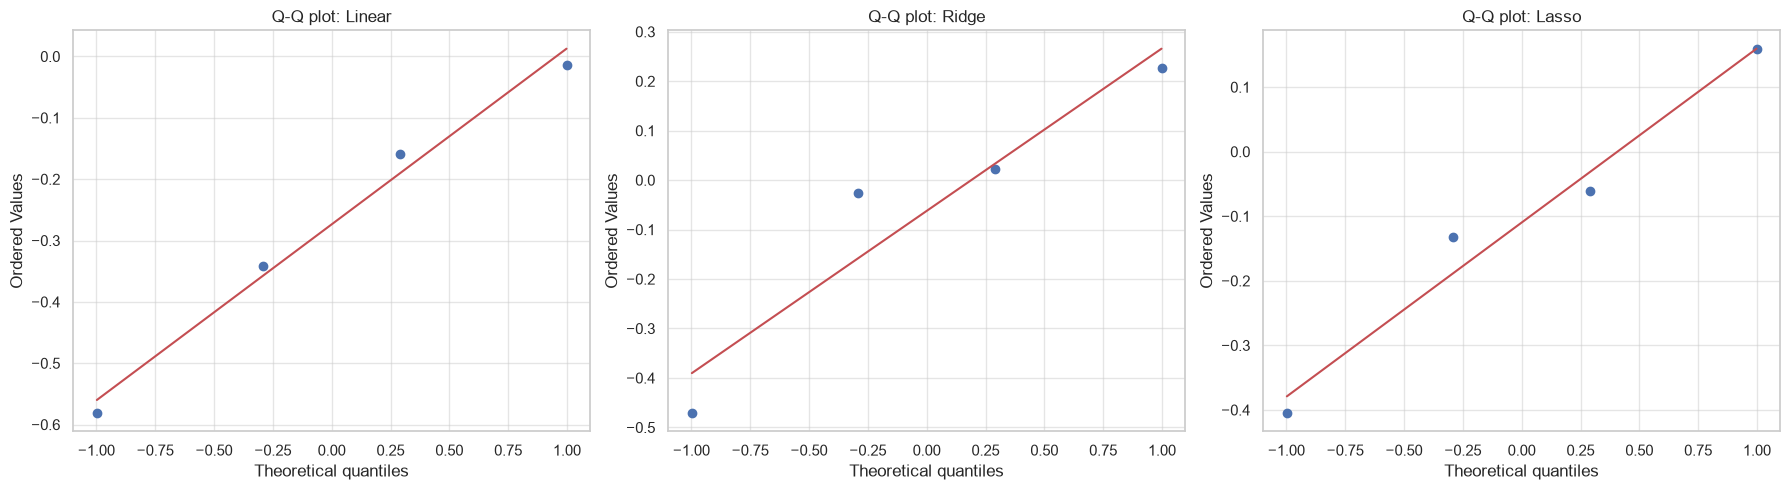

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model_name in zip(axes, residuals.keys()):
    stats.probplot(
        residuals[model_name],
        dist="norm",
        plot=ax
    )
    ax.set_title(f"Q-Q plot: {model_name}")

plt.tight_layout()
plt.show()

In [ ]:
print("Среднее и стандартное отклонение остатков:")

for model_name, resid in residuals.items():
    print(
        f"{model_name}: "
        f"mean={np.mean(resid):.4f}, "
        f"std={np.std(resid):.4f}"
    )

Среднее и стандартное отклонение остатков:
Linear: mean=-0.2736, std=0.2123
Ridge: mean=-0.0622, std=0.2544
Lasso: mean=-0.1097, std=0.2013


### Вывод по остаткам

При хорошем регрессионном моделировании остатки должны быть:
- примерно симметричны вокруг нуля;
- не иметь выраженной зависимости от предсказанного значения;
- не образовывать явных кривых или веерообразных структур;
- на Q-Q plot располагаться приблизительно вдоль диагонали.

На небольшом демонстрационном датасете из 20 строк выводы по графикам следует считать предварительными, поскольку размер тестовой выборки очень мал.

# Задание 4. 10-fold Cross-Validation

Применяем 10-fold cross-validation ко всем трём моделям и сравниваем:
- среднее R²;
- стандартное отклонение;
- 95% доверительный интервал.

Это соответствует структуре проверки из методички.

In [ ]:
def cross_validate_models(X, y):
    """10-fold кросс-валидация для всех моделей"""

    models = {
        "Linear Regression": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Lasso": Lasso(alpha=0.01, max_iter=10000)
    }

    cv_results = {}

    for model_name, model in models.items():

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        scores = cross_val_score(
            pipeline,
            X,
            y,
            cv=10,
            scoring="r2"
        )

        mean_r2 = scores.mean()
        std_r2 = scores.std()

        # 95% доверительный интервал для среднего R²
        ci_margin = 1.96 * std_r2 / np.sqrt(len(scores))

        cv_results[model_name] = {
            "Mean R²": mean_r2,
            "Std R²": std_r2,
            "CI 95% low": mean_r2 - ci_margin,
            "CI 95% high": mean_r2 + ci_margin,
            "Scores": scores
        }

        print(f"{model_name}:")
        print(f"  Среднее R²: {mean_r2:.4f}")
        print(f"  Стд. отклонение: {std_r2:.4f}")
        print(
            f"  95% CI: "
            f"[{mean_r2 - ci_margin:.4f}; "
            f"{mean_r2 + ci_margin:.4f}]"
        )
        print()

    return cv_results

In [ ]:
cv_results = cross_validate_models(X_processed, y_processed)

Linear Regression:
  Среднее R²: -2.6900
  Стд. отклонение: 6.2820
  95% CI: [-6.5836; 1.2037]

Ridge:
  Среднее R²: -2.0010
  Стд. отклонение: 4.6724
  95% CI: [-4.8970; 0.8949]

Lasso:
  Среднее R²: -0.6859
  Стд. отклонение: 1.8952
  95% CI: [-1.8606; 0.4888]



In [ ]:
# Таблица результатов кросс-валидации
cv_table = pd.DataFrame({
    model: {
        "Среднее R²": value["Mean R²"],
        "Стд. отклонение": value["Std R²"],
        "95% CI low": value["CI 95% low"],
        "95% CI high": value["CI 95% high"]
    }
    for model, value in cv_results.items()
}).T

# Приводим названия индекса и столбцов к удобному виду
cv_table.index.name = "Модель"

print("РЕЗУЛЬТАТЫ 10-FOLD CROSS-VALIDATION:")
print("=" * 60)

display(cv_table.round(4))

# Наиболее стабильная модель:
# чем меньше стандартное отклонение R², тем стабильнее модель
most_stable_model = cv_table["Стд. отклонение"].idxmin()

# Модель с лучшим средним R²
best_cv_model = cv_table["Среднее R²"].idxmax()

print(f"\nНаиболее стабильная модель: {most_stable_model}")
print(f"Лучшее среднее R² в CV: {best_cv_model}")

РЕЗУЛЬТАТЫ 10-FOLD CROSS-VALIDATION:


,Среднее R²,Стд. отклонение,95% CI low,95% CI high
Модель,,,,
Linear Regression,-2.6900,6.2820,-6.5836,1.2037
Ridge,-2.0010,4.6724,-4.8970,0.8949
Lasso,-0.6859,1.8952,-1.8606,0.4888



Наиболее стабильная модель: Lasso
Лучшее среднее R² в CV: Lasso


## Сравнение train/test и 10-fold CV

In [ ]:
comparison = pd.DataFrame({
    "Train/Test R²": {
        model: results[model]["r2"]
        for model in results
    },
    "CV mean R²": {
        model: cv_results[model]["Mean R²"]
        for model in cv_results
    },
    "CV std": {
        model: cv_results[model]["Std R²"]
        for model in cv_results
    }
})

display(comparison)

,Train/Test R²,CV mean R²,CV std
Linear,-0.146221,NaN,NaN
Ridge,0.344531,-2.001029,4.672388
Lasso,0.497666,-0.685912,1.895219
Linear Regression,NaN,-2.689971,6.282014


# Итоговые выводы

## Задание 1
Созданы три дополнительных признака:
- `PricePerSqFt` — цена за квадратный фут;
- `AgeCategory` — категория возраста дома;
- `HasGarage` — наличие гаража.

`PricePerSqFt` не используется как входной признак модели, поскольку вычисляется через `SalePrice`.

## Задание 2
`KNNImputer` применён ко всем числовым признакам с пропусками. Качество сравнено с текущим методом заполнения пропусков.

Лучший вариант определяется по R² тестовой выборки в таблице выше.

## Задание 3
Для Linear Regression, Ridge и Lasso построены графики остатков и Q-Q plots. По ним можно оценить наличие систематических ошибок и отклонений от нормальности.

## Задание 4
Для всех моделей выполнена 10-fold cross-validation. Наиболее стабильной считается модель с минимальным стандартным отклонением R².

### Важное ограничение
Демонстрационный набор из методички содержит всего 20 наблюдений, поэтому 10-fold CV даёт очень маленькие тестовые подвыборки. Полученные оценки могут иметь высокую дисперсию. Для полноценной оценки моделей предпочтителен полный Ames Housing Dataset.